In [ ]:
pip install stumpy

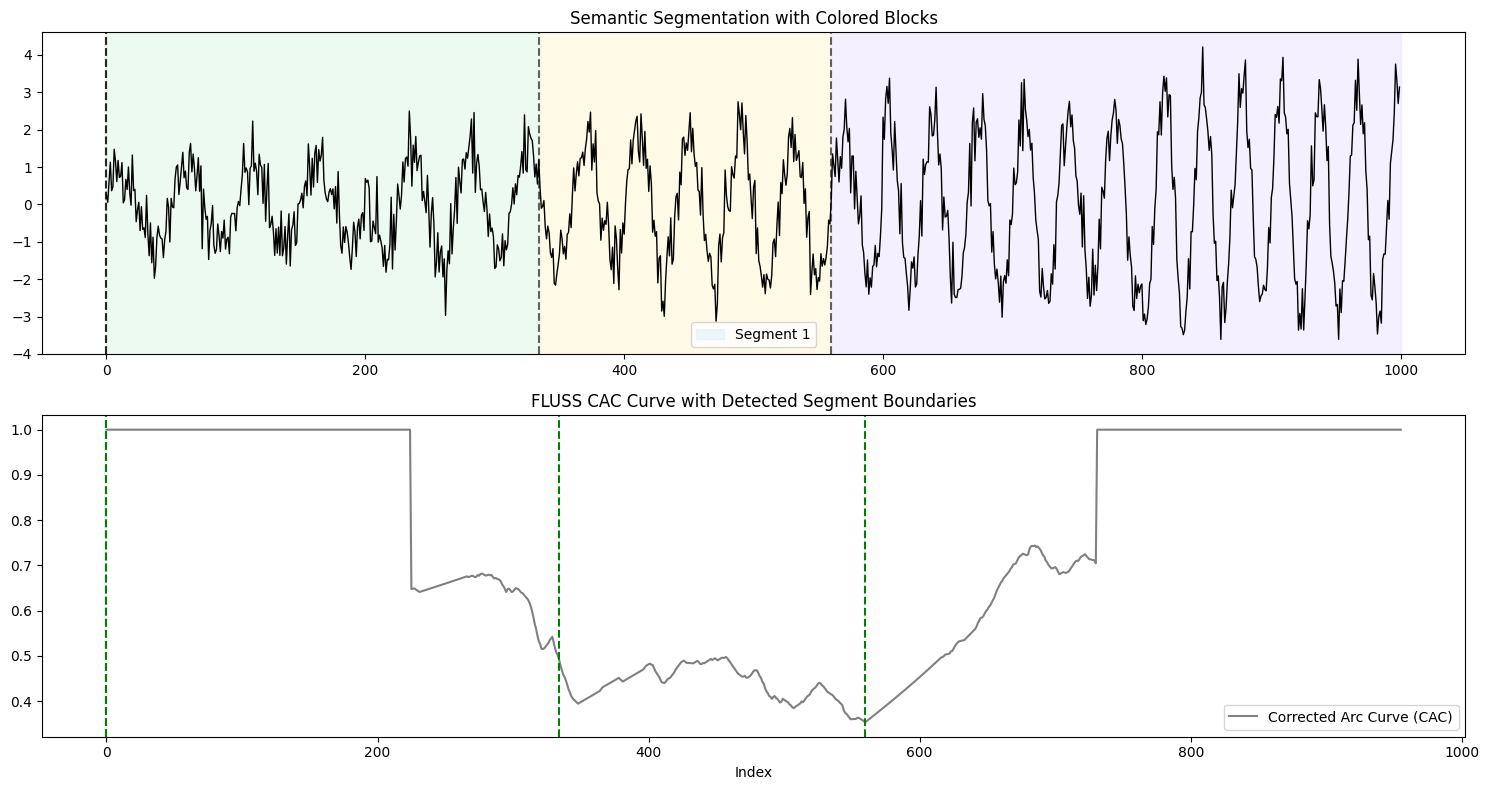

Detected Segmentation Points: [np.int64(0), np.int64(0), np.int64(334), np.int64(560)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy

# 1. Generate synthetic time series with 5 segments
np.random.seed(42)
n = 1000
segment_boundaries = [0, 200, 400, 600, 800, n]  # 5 segments

ts = np.array([])

for i in range(len(segment_boundaries) - 1):
    start = segment_boundaries[i]
    end = segment_boundaries[i + 1]
    t = np.arange(start, end)
    period = 50 - (i * 5)
    amplitude = 1 + 0.5 * i
    segment = amplitude * np.sin(2 * np.pi * t / period) + 0.5 * np.random.randn(len(t))
    ts = np.concatenate((ts, segment))

# 2. Compute Matrix Profile
window_size = 45
mp = stumpy.stump(ts, m=window_size)
mpi = mp[:, 1].astype(int)

# 3. FLUSS: Get segmentation points
n_regimes = 5
cac, segmentation_points = stumpy.fluss(mpi, L=window_size, n_regimes=n_regimes)
segmentation_points = sorted(segmentation_points)
boundaries = [0] + segmentation_points + [len(ts)]

# 4. Plot with colored background blocks
colors = ['#d0ebff', '#ffd6d6', '#d4f4dd', '#fff3bf', '#e5dbff', '#ffc9de']

plt.figure(figsize=(15, 8))

# Top plot: time series with background segment blocks
plt.subplot(2, 1, 1)

# Plot background colored blocks
for i in range(len(boundaries) - 1):
    start = boundaries[i]
    end = boundaries[i + 1]
    plt.axvspan(start, end, color=colors[i % len(colors)], alpha=0.4, label=f'Segment {i+1}' if i == 0 else None)

# Plot signal on top of background
plt.plot(ts, color='black', linewidth=1)
for pt in segmentation_points:
    plt.axvline(pt, color='black', linestyle='--', alpha=0.6)
plt.title('Semantic Segmentation with Colored Blocks')
plt.legend()

# Bottom plot: CAC curve
plt.subplot(2, 1, 2)
plt.plot(cac, label='Corrected Arc Curve (CAC)', color='gray')
for pt in segmentation_points:
    plt.axvline(pt, color='green', linestyle='--')
plt.title('FLUSS CAC Curve with Detected Segment Boundaries')
plt.xlabel('Index')
plt.legend()

plt.tight_layout()
plt.show()

# Print detected points
print(f"Detected Segmentation Points: {segmentation_points}")
